# CGM Forecasting Research
## OhioT1DM and Shanghai Experimental Workflow

This notebook documents the experimental workflow used for continuous glucose monitoring (CGM) forecasting.

The experiments include:

- Patient-wise forecasting on the OhioT1DM dataset
- 15-minute, 30-minute, and 60-minute prediction horizons
- Comparison of LSTM, GRU, BiLSTM, TCN, and Transformer architectures
- Clinical evaluation using RMSE, MAE, MARD, Time Lag, and Clarke Error Grid
- Patient-wise results and Mean ± SD summaries
- Feature-ablation experiments using wearable signals
- Initial experiments on the Shanghai T1DM dataset
- Statistical analysis of model performance

The detailed implementation is maintained in the Python scripts in this repository. This notebook provides a reproducible walkthrough of the preprocessing, experimental configuration, evaluation procedures, and generated results.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Repository root
REPO_ROOT = Path.cwd()

print("Repository:", REPO_ROOT)

Repository: /Users/sulabhyadav/Desktop/CGM Forecasting Research


In [3]:
required_files = [
    "multimodel_architecture_compare.py",
    "multimodel_compare_all.py",
    "clinical_metrics.py",
    "significance_test.py",
    "shanghai_preprocessing.py",
    "shanghai_architecture_compare.py",
]

print("Repository files:")
print("-" * 50)

for file in required_files:
    path = REPO_ROOT / file
    print(f"{'✓' if path.exists() else '✗'} {file}")

Repository files:
--------------------------------------------------
✓ multimodel_architecture_compare.py
✓ multimodel_compare_all.py
✓ clinical_metrics.py
✓ significance_test.py
✓ shanghai_preprocessing.py
✓ shanghai_architecture_compare.py


## 1. Experimental Configuration

### OhioT1DM Dataset

The OhioT1DM experiments include 12 patients:

- 2018 cohort: 559, 563, 570, 575, 588, 591
- 2020 cohort: 540, 544, 552, 567, 584, 596

The CGM sampling interval is 5 minutes.

Three forecasting horizons are evaluated:

- 15 minutes
- 30 minutes
- 60 minutes

The input window is 60 minutes.

The architecture comparison includes:

- LSTM
- GRU
- BiLSTM
- TCN
- Transformer

In [4]:
PATIENT_IDS_2018 = [559, 563, 570, 575, 588, 591]
PATIENT_IDS_2020 = [540, 544, 552, 567, 584, 596]

PATIENT_IDS = PATIENT_IDS_2018 + PATIENT_IDS_2020

HORIZONS = {
    "15min": 3,
    "30min": 6,
    "60min": 12
}

WINDOW = 12
SAMPLE_INTERVAL_MIN = 5

print("Number of patients:", len(PATIENT_IDS))
print("Patients:", PATIENT_IDS)
print("Horizons:", HORIZONS)
print("Input window:", WINDOW * SAMPLE_INTERVAL_MIN, "minutes")

Number of patients: 12
Patients: [559, 563, 570, 575, 588, 591, 540, 544, 552, 567, 584, 596]
Horizons: {'15min': 3, '30min': 6, '60min': 12}
Input window: 60 minutes


## 2. OhioT1DM Architecture Comparison Results

The OhioT1DM architecture comparison evaluates five forecasting architectures across all 12 patients and three prediction horizons:

- LSTM
- GRU
- BiLSTM
- TCN
- Transformer

The generated patient-wise results are stored in the `output/` directory.

In [5]:
# Load existing OhioT1DM architecture comparison results

output_dir = REPO_ROOT / "output"

ohio_results_path = output_dir / "architecture_all12_results.csv"
ohio_summary_path = output_dir / "architecture_all12_summary_mean_sd.csv"

ohio_results = pd.read_csv(ohio_results_path)
ohio_summary = pd.read_csv(ohio_summary_path)

print("Patient-wise results:")
print(f"Shape: {ohio_results.shape}")

display(ohio_results.head())

print("\nMean ± SD summary:")
print(f"Shape: {ohio_summary.shape}")

display(ohio_summary.head())

Patient-wise results:
Shape: (180, 12)


,Patient,Horizon,Architecture,RMSE,MAE,MARD,TimeLag_min,CEGA_A_%,CEGA_B_%,CEGA_C_%,CEGA_D_%,CEGA_E_%
0,559,15min,LSTM,18.48,12.18,8.36,0.0,91.76,7.64,0.16,0.44,0.0
1,559,15min,GRU,18.24,12.61,8.28,0.0,93.00,6.44,0.16,0.40,0.0
2,559,15min,BiLSTM,17.94,11.96,7.83,0.0,92.84,6.60,0.16,0.40,0.0
3,559,15min,TCN,22.56,15.86,11.03,0.0,87.39,10.28,0.20,2.12,0.0
4,559,15min,Transformer,31.45,22.83,15.16,0.0,75.47,21.61,0.72,2.20,0.0



Mean ± SD summary:
Shape: (15, 12)


,Horizon,Architecture,n_patients,RMSE,MAE,MARD,TimeLag_min,CEGA_A_%,CEGA_B_%,CEGA_C_%,CEGA_D_%,CEGA_E_%
0,15min,BiLSTM,12,18.71 ± 3.16,13.12 ± 2.09,8.94 ± 1.62,0.00 ± 0.00,90.05 ± 3.99,8.50 ± 3.50,0.05 ± 0.09,1.41 ± 1.12,0.00 ± 0.00
1,15min,GRU,12,17.32 ± 2.75,12.00 ± 1.53,8.10 ± 1.22,0.00 ± 0.00,92.33 ± 2.73,6.52 ± 2.38,0.04 ± 0.09,1.11 ± 0.89,0.00 ± 0.00
2,15min,LSTM,12,18.81 ± 3.40,13.21 ± 2.51,9.01 ± 1.73,0.00 ± 0.00,90.00 ± 3.94,8.50 ± 3.12,0.04 ± 0.09,1.46 ± 1.33,0.00 ± 0.00
3,15min,TCN,12,24.89 ± 5.85,18.15 ± 4.52,12.33 ± 3.13,0.00 ± 0.00,81.99 ± 7.94,15.52 ± 6.93,0.05 ± 0.14,2.44 ± 1.87,0.00 ± 0.00
4,15min,Transformer,12,31.04 ± 4.66,22.85 ± 3.20,15.86 ± 3.01,0.00 ± 0.00,72.87 ± 8.01,24.11 ± 6.57,0.18 ± 0.33,2.83 ± 1.97,0.01 ± 0.05


In [6]:
print("Patient-wise result columns:")
print(ohio_results.columns.tolist())

print("\nSummary columns:")
print(ohio_summary.columns.tolist())

Patient-wise result columns:
['Patient', 'Horizon', 'Architecture', 'RMSE', 'MAE', 'MARD', 'TimeLag_min', 'CEGA_A_%', 'CEGA_B_%', 'CEGA_C_%', 'CEGA_D_%', 'CEGA_E_%']

Summary columns:
['Horizon', 'Architecture', 'n_patients', 'RMSE', 'MAE', 'MARD', 'TimeLag_min', 'CEGA_A_%', 'CEGA_B_%', 'CEGA_C_%', 'CEGA_D_%', 'CEGA_E_%']


## 3. Patient-wise OhioT1DM Results

The following table contains the patient-wise performance of each forecasting architecture at each prediction horizon.

Each row corresponds to one patient–horizon–architecture combination.

In [7]:
# Display patient-wise OhioT1DM results

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

display(ohio_results)

,Patient,Horizon,Architecture,RMSE,MAE,MARD,TimeLag_min,CEGA_A_%,CEGA_B_%,CEGA_C_%,CEGA_D_%,CEGA_E_%
0,559,15min,LSTM,18.48,12.18,8.36,0.0,91.76,7.64,0.16,0.44,0.0
1,559,15min,GRU,18.24,12.61,8.28,0.0,93.00,6.44,0.16,0.40,0.0
2,559,15min,BiLSTM,17.94,11.96,7.83,0.0,92.84,6.60,0.16,0.40,0.0
3,559,15min,TCN,22.56,15.86,11.03,0.0,87.39,10.28,0.20,2.12,0.0
4,559,15min,Transformer,31.45,22.83,15.16,0.0,75.47,21.61,0.72,2.20,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
175,596,60min,LSTM,30.32,22.61,17.49,0.0,68.92,27.88,0.00,3.20,0.0
176,596,60min,GRU,31.06,23.70,18.05,0.0,69.81,27.11,0.00,3.09,0.0
177,596,60min,BiLSTM,30.47,22.67,17.12,0.0,69.84,27.00,0.00,3.16,0.0
178,596,60min,TCN,35.35,26.65,19.79,0.0,62.45,33.39,0.00,4.16,0.0


In [8]:
print("Number of patient-level rows:", len(ohio_results))
print("Unique patients:", ohio_results["Patient"].nunique())
print("Patients:", sorted(ohio_results["Patient"].unique()))

print("\nHorizons:")
print(ohio_results["Horizon"].unique())

print("\nArchitectures:")
print(ohio_results["Architecture"].unique())

Number of patient-level rows: 180
Unique patients: 12
Patients: [np.int64(540), np.int64(544), np.int64(552), np.int64(559), np.int64(563), np.int64(567), np.int64(570), np.int64(575), np.int64(584), np.int64(588), np.int64(591), np.int64(596)]

Horizons:
['15min' '30min' '60min']

Architectures:
['LSTM' 'GRU' 'BiLSTM' 'TCN' 'Transformer']


In [9]:
# Check whether every patient has results for every
# horizon and every architecture

expected_combinations = (
    len(PATIENT_IDS)
    * len(HORIZONS)
    * ohio_results["Architecture"].nunique()
)

actual_combinations = len(ohio_results)

print("Expected combinations:", expected_combinations)
print("Actual combinations:", actual_combinations)

if expected_combinations == actual_combinations:
    print("✓ All expected patient-horizon-architecture combinations are present.")
else:
    print("⚠ Some expected combinations may be missing.")

Expected combinations: 180
Actual combinations: 180
✓ All expected patient-horizon-architecture combinations are present.


In [10]:
# Check for duplicate experiment combinations

duplicates = ohio_results.duplicated(
    subset=["Patient", "Horizon", "Architecture"]
).sum()

print("Duplicate combinations:", duplicates)

if duplicates == 0:
    print("✓ No duplicate patient-horizon-architecture combinations found.")
else:
    print("⚠ Duplicate combinations found.")

Duplicate combinations: 0
✓ No duplicate patient-horizon-architecture combinations found.


## 4. Mean ± SD Summary Across Patients

The patient-wise results are aggregated across the 12 OhioT1DM patients for each forecasting horizon and architecture.

The summary retains the number of patients (`n_patients`) used for each aggregation.

In [11]:
# Display the saved Mean ± SD summary

display(ohio_summary)

,Horizon,Architecture,n_patients,RMSE,MAE,MARD,TimeLag_min,CEGA_A_%,CEGA_B_%,CEGA_C_%,CEGA_D_%,CEGA_E_%
0,15min,BiLSTM,12,18.71 ± 3.16,13.12 ± 2.09,8.94 ± 1.62,0.00 ± 0.00,90.05 ± 3.99,8.50 ± 3.50,0.05 ± 0.09,1.41 ± 1.12,0.00 ± 0.00
1,15min,GRU,12,17.32 ± 2.75,12.00 ± 1.53,8.10 ± 1.22,0.00 ± 0.00,92.33 ± 2.73,6.52 ± 2.38,0.04 ± 0.09,1.11 ± 0.89,0.00 ± 0.00
2,15min,LSTM,12,18.81 ± 3.40,13.21 ± 2.51,9.01 ± 1.73,0.00 ± 0.00,90.00 ± 3.94,8.50 ± 3.12,0.04 ± 0.09,1.46 ± 1.33,0.00 ± 0.00
3,15min,TCN,12,24.89 ± 5.85,18.15 ± 4.52,12.33 ± 3.13,0.00 ± 0.00,81.99 ± 7.94,15.52 ± 6.93,0.05 ± 0.14,2.44 ± 1.87,0.00 ± 0.00
4,15min,Transformer,12,31.04 ± 4.66,22.85 ± 3.20,15.86 ± 3.01,0.00 ± 0.00,72.87 ± 8.01,24.11 ± 6.57,0.18 ± 0.33,2.83 ± 1.97,0.01 ± 0.05
5,30min,BiLSTM,12,26.16 ± 3.90,19.03 ± 2.71,13.16 ± 2.71,0.00 ± 0.00,79.57 ± 7.36,17.68 ± 5.87,0.15 ± 0.22,2.60 ± 1.90,0.00 ± 0.00
6,30min,GRU,12,24.89 ± 3.35,17.75 ± 2.18,12.08 ± 2.23,0.00 ± 0.00,81.95 ± 6.26,15.71 ± 4.84,0.08 ± 0.17,2.26 ± 1.73,0.00 ± 0.00
7,30min,LSTM,12,25.96 ± 3.85,18.80 ± 2.73,12.84 ± 2.49,0.00 ± 0.00,80.35 ± 7.01,17.09 ± 5.66,0.10 ± 0.18,2.46 ± 1.91,0.00 ± 0.00
8,30min,TCN,12,31.48 ± 4.20,23.02 ± 3.27,15.64 ± 2.90,0.00 ± 0.00,73.27 ± 6.72,23.58 ± 5.50,0.19 ± 0.23,2.96 ± 1.84,0.00 ± 0.00
9,30min,Transformer,12,36.58 ± 5.17,27.33 ± 3.80,19.28 ± 4.30,0.00 ± 0.00,65.82 ± 9.33,30.13 ± 7.46,0.30 ± 0.36,3.72 ± 2.44,0.03 ± 0.07


In [13]:
print("Summary shape:", ohio_summary.shape)

print("\nSummary columns:")
print(ohio_summary.columns.tolist())

Summary shape: (15, 12)

Summary columns:
['Horizon', 'Architecture', 'n_patients', 'RMSE', 'MAE', 'MARD', 'TimeLag_min', 'CEGA_A_%', 'CEGA_B_%', 'CEGA_C_%', 'CEGA_D_%', 'CEGA_E_%']


## 5. Verification of Patient Coverage

Before interpreting the aggregate results, we verify that each horizon–architecture combination contains results from all 12 OhioT1DM patients.

In [14]:
# Check the number of patients represented in each
# horizon-architecture combination

coverage_check = (
    ohio_results
    .groupby(["Horizon", "Architecture"])["Patient"]
    .nunique()
    .reset_index(name="n_patients")
)

display(coverage_check)

,Horizon,Architecture,n_patients
0,15min,BiLSTM,12
1,15min,GRU,12
2,15min,LSTM,12
3,15min,TCN,12
4,15min,Transformer,12
5,30min,BiLSTM,12
6,30min,GRU,12
7,30min,LSTM,12
8,30min,TCN,12
9,30min,Transformer,12


In [15]:
# Verify that every combination contains all 12 patients

if (coverage_check["n_patients"] == 12).all():
    print("✓ Every horizon-architecture combination contains all 12 patients.")
else:
    print("⚠ Some horizon-architecture combinations do not contain all 12 patients.")

print("\nPatient counts:")
print(coverage_check["n_patients"].value_counts().sort_index())

✓ Every horizon-architecture combination contains all 12 patients.

Patient counts:
n_patients
12    15
Name: count, dtype: int64


## 6. Architecture Performance Comparison

The following tables compare the five forecasting architectures across the 15-minute, 30-minute, and 60-minute prediction horizons.

The comparison is based on the Mean ± SD summary across the 12 OhioT1DM patients.

In [16]:
# Compare RMSE and MAE across architectures and horizons

performance_table = ohio_summary[
    ["Horizon", "Architecture", "RMSE", "MAE"]
].copy()

display(
    performance_table
    .sort_values(["Horizon", "Architecture"])
    .reset_index(drop=True)
)

,Horizon,Architecture,RMSE,MAE
0,15min,BiLSTM,18.71 ± 3.16,13.12 ± 2.09
1,15min,GRU,17.32 ± 2.75,12.00 ± 1.53
2,15min,LSTM,18.81 ± 3.40,13.21 ± 2.51
3,15min,TCN,24.89 ± 5.85,18.15 ± 4.52
4,15min,Transformer,31.04 ± 4.66,22.85 ± 3.20
5,30min,BiLSTM,26.16 ± 3.90,19.03 ± 2.71
6,30min,GRU,24.89 ± 3.35,17.75 ± 2.18
7,30min,LSTM,25.96 ± 3.85,18.80 ± 2.73
8,30min,TCN,31.48 ± 4.20,23.02 ± 3.27
9,30min,Transformer,36.58 ± 5.17,27.33 ± 3.80


In [17]:
# Display the main clinical evaluation metrics

clinical_table = ohio_summary[
    [
        "Horizon",
        "Architecture",
        "MARD",
        "TimeLag_min",
        "CEGA_A_%",
        "CEGA_B_%",
        "CEGA_C_%",
        "CEGA_D_%",
        "CEGA_E_%"
    ]
].copy()

display(
    clinical_table
    .sort_values(["Horizon", "Architecture"])
    .reset_index(drop=True)
)

,Horizon,Architecture,MARD,TimeLag_min,CEGA_A_%,CEGA_B_%,CEGA_C_%,CEGA_D_%,CEGA_E_%
0,15min,BiLSTM,8.94 ± 1.62,0.00 ± 0.00,90.05 ± 3.99,8.50 ± 3.50,0.05 ± 0.09,1.41 ± 1.12,0.00 ± 0.00
1,15min,GRU,8.10 ± 1.22,0.00 ± 0.00,92.33 ± 2.73,6.52 ± 2.38,0.04 ± 0.09,1.11 ± 0.89,0.00 ± 0.00
2,15min,LSTM,9.01 ± 1.73,0.00 ± 0.00,90.00 ± 3.94,8.50 ± 3.12,0.04 ± 0.09,1.46 ± 1.33,0.00 ± 0.00
3,15min,TCN,12.33 ± 3.13,0.00 ± 0.00,81.99 ± 7.94,15.52 ± 6.93,0.05 ± 0.14,2.44 ± 1.87,0.00 ± 0.00
4,15min,Transformer,15.86 ± 3.01,0.00 ± 0.00,72.87 ± 8.01,24.11 ± 6.57,0.18 ± 0.33,2.83 ± 1.97,0.01 ± 0.05
5,30min,BiLSTM,13.16 ± 2.71,0.00 ± 0.00,79.57 ± 7.36,17.68 ± 5.87,0.15 ± 0.22,2.60 ± 1.90,0.00 ± 0.00
6,30min,GRU,12.08 ± 2.23,0.00 ± 0.00,81.95 ± 6.26,15.71 ± 4.84,0.08 ± 0.17,2.26 ± 1.73,0.00 ± 0.00
7,30min,LSTM,12.84 ± 2.49,0.00 ± 0.00,80.35 ± 7.01,17.09 ± 5.66,0.10 ± 0.18,2.46 ± 1.91,0.00 ± 0.00
8,30min,TCN,15.64 ± 2.90,0.00 ± 0.00,73.27 ± 6.72,23.58 ± 5.50,0.19 ± 0.23,2.96 ± 1.84,0.00 ± 0.00
9,30min,Transformer,19.28 ± 4.30,0.00 ± 0.00,65.82 ± 9.33,30.13 ± 7.46,0.30 ± 0.36,3.72 ± 2.44,0.03 ± 0.07


### RMSE Across Forecasting Horizons

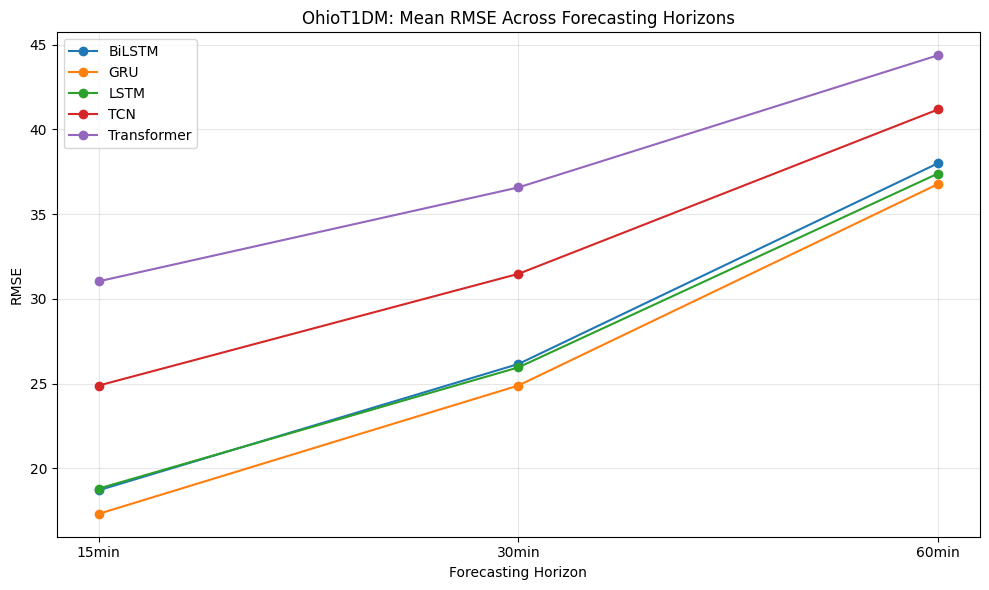

In [19]:
# Convert the Mean ± SD RMSE values to numeric means for plotting

def extract_mean(value):
    """Extract the mean value from strings such as '18.71 ± 3.16'."""
    if isinstance(value, str) and "±" in value:
        return float(value.split("±")[0].strip())
    return float(value)


rmse_plot = ohio_summary.copy()

rmse_plot["RMSE_mean"] = rmse_plot["RMSE"].apply(extract_mean)

# Ensure horizons appear in the correct chronological order
horizon_order = ["15min", "30min", "60min"]

rmse_plot["Horizon"] = pd.Categorical(
    rmse_plot["Horizon"],
    categories=horizon_order,
    ordered=True
)

rmse_plot = rmse_plot.sort_values("Horizon")

# Plot
plt.figure(figsize=(10, 6))

for architecture in rmse_plot["Architecture"].unique():
    subset = rmse_plot[
        rmse_plot["Architecture"] == architecture
    ]

    plt.plot(
        subset["Horizon"],
        subset["RMSE_mean"],
        marker="o",
        label=architecture
    )

plt.xlabel("Forecasting Horizon")
plt.ylabel("RMSE")
plt.title("OhioT1DM: Mean RMSE Across Forecasting Horizons")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### MARD Across Forecasting Horizons

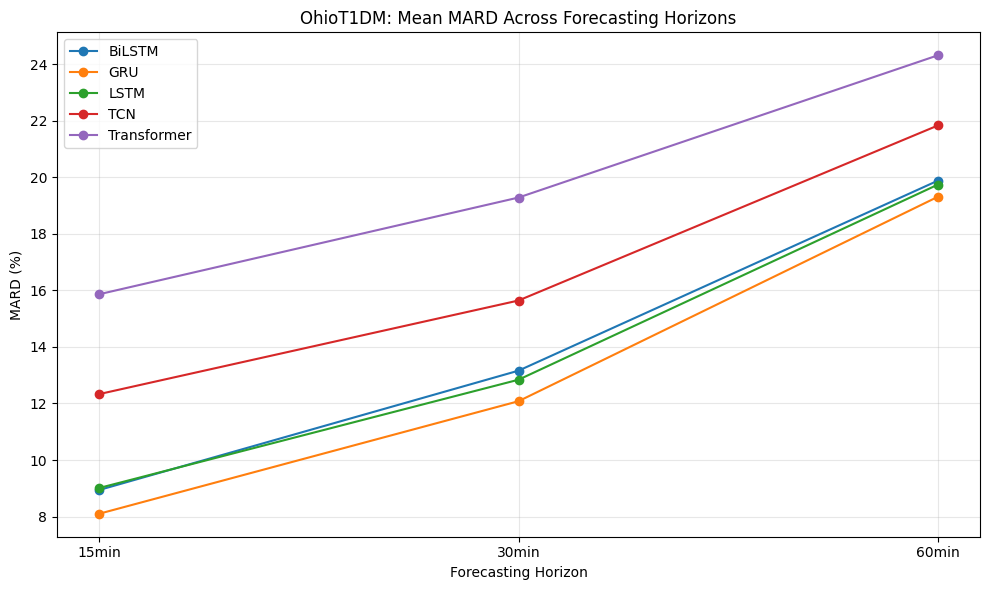

In [21]:
# Extract numeric MARD means for plotting

mard_plot = ohio_summary.copy()
mard_plot["MARD_mean"] = mard_plot["MARD"].apply(extract_mean)

mard_plot["Horizon"] = pd.Categorical(
    mard_plot["Horizon"],
    categories=["15min", "30min", "60min"],
    ordered=True
)

mard_plot = mard_plot.sort_values("Horizon")

plt.figure(figsize=(10, 6))

for architecture in mard_plot["Architecture"].unique():
    subset = mard_plot[mard_plot["Architecture"] == architecture]

    plt.plot(
        subset["Horizon"],
        subset["MARD_mean"],
        marker="o",
        label=architecture
    )

plt.xlabel("Forecasting Horizon")
plt.ylabel("MARD (%)")
plt.title("OhioT1DM: Mean MARD Across Forecasting Horizons")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Clarke Error Grid Analysis

Clarke Error Grid Analysis (CEGA) evaluates the clinical significance of glucose prediction errors by assigning predictions to zones A–E.

The results below show the distribution of predictions across the CEGA zones for each forecasting architecture and horizon.

In [22]:
# Display Clarke Error Grid zone distributions

cega_columns = [
    "Horizon",
    "Architecture",
    "CEGA_A_%",
    "CEGA_B_%",
    "CEGA_C_%",
    "CEGA_D_%",
    "CEGA_E_%"
]

cega_table = ohio_summary[cega_columns].copy()

display(
    cega_table
    .sort_values(["Horizon", "Architecture"])
    .reset_index(drop=True)
)

,Horizon,Architecture,CEGA_A_%,CEGA_B_%,CEGA_C_%,CEGA_D_%,CEGA_E_%
0,15min,BiLSTM,90.05 ± 3.99,8.50 ± 3.50,0.05 ± 0.09,1.41 ± 1.12,0.00 ± 0.00
1,15min,GRU,92.33 ± 2.73,6.52 ± 2.38,0.04 ± 0.09,1.11 ± 0.89,0.00 ± 0.00
2,15min,LSTM,90.00 ± 3.94,8.50 ± 3.12,0.04 ± 0.09,1.46 ± 1.33,0.00 ± 0.00
3,15min,TCN,81.99 ± 7.94,15.52 ± 6.93,0.05 ± 0.14,2.44 ± 1.87,0.00 ± 0.00
4,15min,Transformer,72.87 ± 8.01,24.11 ± 6.57,0.18 ± 0.33,2.83 ± 1.97,0.01 ± 0.05
5,30min,BiLSTM,79.57 ± 7.36,17.68 ± 5.87,0.15 ± 0.22,2.60 ± 1.90,0.00 ± 0.00
6,30min,GRU,81.95 ± 6.26,15.71 ± 4.84,0.08 ± 0.17,2.26 ± 1.73,0.00 ± 0.00
7,30min,LSTM,80.35 ± 7.01,17.09 ± 5.66,0.10 ± 0.18,2.46 ± 1.91,0.00 ± 0.00
8,30min,TCN,73.27 ± 6.72,23.58 ± 5.50,0.19 ± 0.23,2.96 ± 1.84,0.00 ± 0.00
9,30min,Transformer,65.82 ± 9.33,30.13 ± 7.46,0.30 ± 0.36,3.72 ± 2.44,0.03 ± 0.07


### CEGA Zone A Distribution

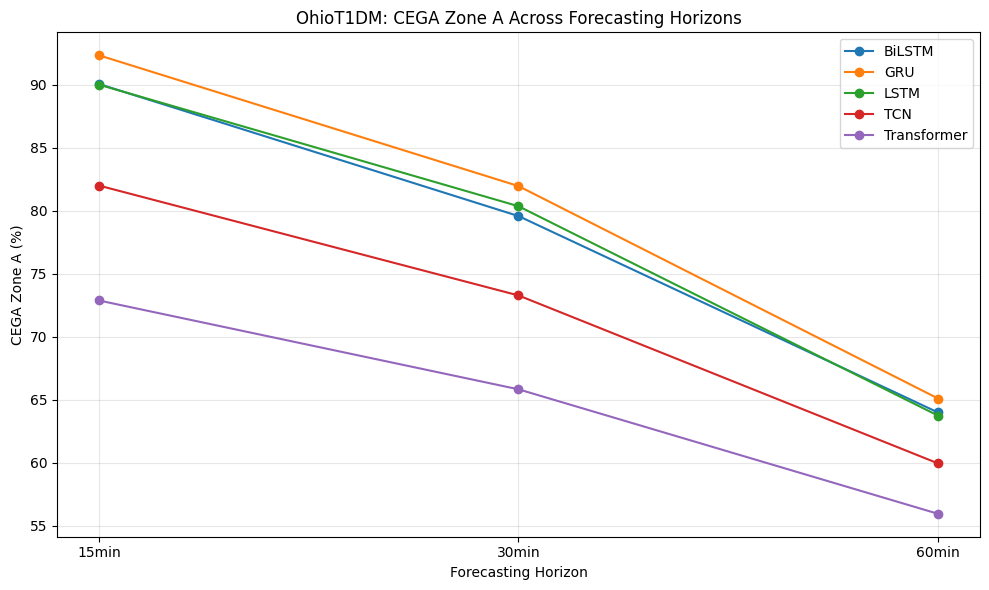

In [23]:
# Convert CEGA-A values to numeric means and plot

cega_plot = ohio_summary.copy()
cega_plot["CEGA_A_mean"] = cega_plot["CEGA_A_%"].apply(extract_mean)

cega_plot["Horizon"] = pd.Categorical(
    cega_plot["Horizon"],
    categories=["15min", "30min", "60min"],
    ordered=True
)

cega_plot = cega_plot.sort_values("Horizon")

plt.figure(figsize=(10, 6))

for architecture in cega_plot["Architecture"].unique():
    subset = cega_plot[
        cega_plot["Architecture"] == architecture
    ]

    plt.plot(
        subset["Horizon"],
        subset["CEGA_A_mean"],
        marker="o",
        label=architecture
    )

plt.xlabel("Forecasting Horizon")
plt.ylabel("CEGA Zone A (%)")
plt.title("OhioT1DM: CEGA Zone A Across Forecasting Horizons")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 8. Time Lag Analysis

Time Lag measures the temporal alignment between the predicted and reference glucose signals.

The reported values are summarized across the 12 OhioT1DM patients for each forecasting architecture and prediction horizon.

In [24]:
# Display Time Lag results

timelag_table = ohio_summary[
    ["Horizon", "Architecture", "TimeLag_min"]
].copy()

display(
    timelag_table
    .sort_values(["Horizon", "Architecture"])
    .reset_index(drop=True)
)

,Horizon,Architecture,TimeLag_min
0,15min,BiLSTM,0.00 ± 0.00
1,15min,GRU,0.00 ± 0.00
2,15min,LSTM,0.00 ± 0.00
3,15min,TCN,0.00 ± 0.00
4,15min,Transformer,0.00 ± 0.00
5,30min,BiLSTM,0.00 ± 0.00
6,30min,GRU,0.00 ± 0.00
7,30min,LSTM,0.00 ± 0.00
8,30min,TCN,0.00 ± 0.00
9,30min,Transformer,0.00 ± 0.00


### Mean Time Lag Across Forecasting Horizons

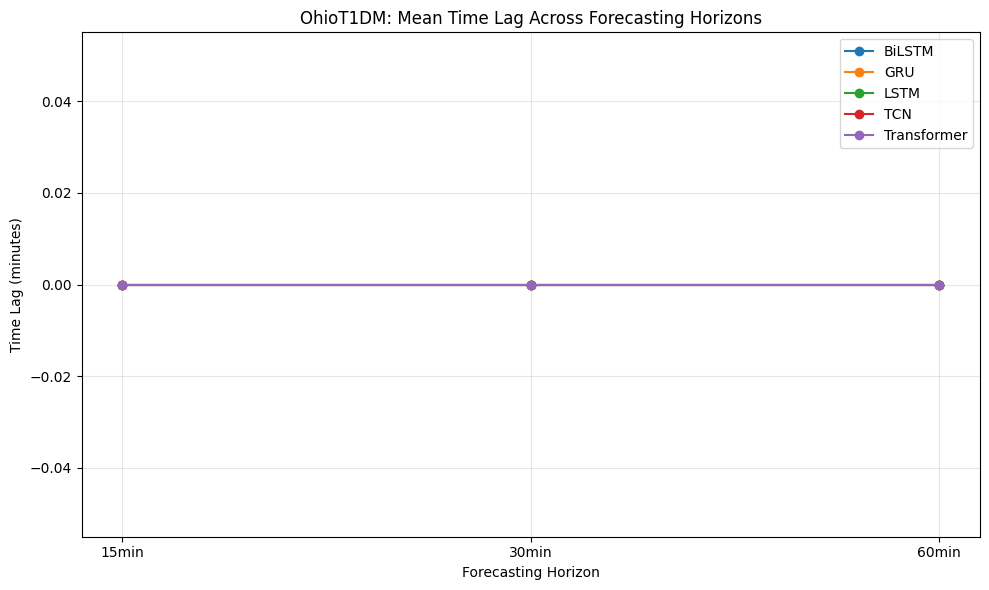

In [25]:
# Extract numeric Time Lag means for plotting

timelag_plot = ohio_summary.copy()

timelag_plot["TimeLag_mean"] = (
    timelag_plot["TimeLag_min"].apply(extract_mean)
)

timelag_plot["Horizon"] = pd.Categorical(
    timelag_plot["Horizon"],
    categories=["15min", "30min", "60min"],
    ordered=True
)

timelag_plot = timelag_plot.sort_values("Horizon")

plt.figure(figsize=(10, 6))

for architecture in timelag_plot["Architecture"].unique():
    subset = timelag_plot[
        timelag_plot["Architecture"] == architecture
    ]

    plt.plot(
        subset["Horizon"],
        subset["TimeLag_mean"],
        marker="o",
        label=architecture
    )

plt.xlabel("Forecasting Horizon")
plt.ylabel("Time Lag (minutes)")
plt.title("OhioT1DM: Mean Time Lag Across Forecasting Horizons")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 9. Feature Ablation: Wearable Signals

A separate experiment evaluates the effect of adding wearable-derived signals to the CGM forecasting input.

The 2018 OhioT1DM wearable experiment compares forecasting performance using the available glucose, insulin, carbohydrate, sleep, and wearable features.

The generated results are stored separately from the main 12-patient architecture comparison.

In [26]:
# Load the wearable feature experiment results

wearable_results_path = (
    output_dir / "architecture_2018_wearable_results.csv"
)

wearable_summary_path = (
    output_dir / "architecture_2018_wearable_summary_mean_sd.csv"
)

wearable_results = pd.read_csv(wearable_results_path)
wearable_summary = pd.read_csv(wearable_summary_path)

print("Wearable experiment results:")
print("Shape:", wearable_results.shape)

display(wearable_results.head())

print("\nWearable experiment summary:")
print("Shape:", wearable_summary.shape)

display(wearable_summary.head())

Wearable experiment results:
Shape: (90, 12)


,Patient,Horizon,Architecture,RMSE,MAE,MARD,TimeLag_min,CEGA_A_%,CEGA_B_%,CEGA_C_%,CEGA_D_%,CEGA_E_%
0,559,15min,LSTM,19.04,12.72,8.83,0.0,90.52,8.84,0.16,0.48,0.00
1,559,15min,GRU,17.08,11.34,8.04,0.0,92.44,6.68,0.16,0.72,0.00
2,559,15min,BiLSTM,22.34,15.54,10.28,0.0,87.92,11.20,0.16,0.72,0.00
3,559,15min,TCN,26.36,18.71,12.61,0.0,82.75,14.45,0.24,2.56,0.00
4,559,15min,Transformer,31.98,23.20,15.80,0.0,74.63,22.73,0.52,2.08,0.04



Wearable experiment summary:
Shape: (15, 12)


,Horizon,Architecture,n_patients,RMSE,MAE,MARD,TimeLag_min,CEGA_A_%,CEGA_B_%,CEGA_C_%,CEGA_D_%,CEGA_E_%
0,15min,BiLSTM,6,19.83 ± 2.87,13.91 ± 2.15,8.96 ± 1.70,0.00 ± 0.00,89.78 ± 4.06,9.19 ± 3.92,0.03 ± 0.07,1.00 ± 0.94,0.00 ± 0.00
1,15min,GRU,6,18.00 ± 2.52,12.58 ± 2.05,8.14 ± 1.39,0.00 ± 0.00,92.20 ± 3.13,6.84 ± 2.75,0.03 ± 0.07,0.93 ± 0.84,0.00 ± 0.00
2,15min,LSTM,6,18.94 ± 2.81,13.37 ± 2.34,8.82 ± 1.86,0.00 ± 0.00,90.32 ± 3.99,8.50 ± 3.33,0.04 ± 0.07,1.15 ± 1.22,0.00 ± 0.00
3,15min,TCN,6,25.22 ± 4.05,18.36 ± 3.31,11.59 ± 1.69,0.00 ± 0.00,84.11 ± 4.83,14.02 ± 4.56,0.07 ± 0.10,1.80 ± 1.26,0.00 ± 0.00
4,15min,Transformer,6,30.34 ± 3.00,22.22 ± 2.16,14.90 ± 3.04,0.00 ± 0.00,75.08 ± 7.50,22.45 ± 6.07,0.33 ± 0.36,2.15 ± 1.96,0.01 ± 0.02


In [27]:
print("Wearable result columns:")
print(wearable_results.columns.tolist())

print("\nWearable summary columns:")
print(wearable_summary.columns.tolist())

Wearable result columns:
['Patient', 'Horizon', 'Architecture', 'RMSE', 'MAE', 'MARD', 'TimeLag_min', 'CEGA_A_%', 'CEGA_B_%', 'CEGA_C_%', 'CEGA_D_%', 'CEGA_E_%']

Wearable summary columns:
['Horizon', 'Architecture', 'n_patients', 'RMSE', 'MAE', 'MARD', 'TimeLag_min', 'CEGA_A_%', 'CEGA_B_%', 'CEGA_C_%', 'CEGA_D_%', 'CEGA_E_%']


## 10. Wearable Feature Experiment: Patient Coverage

The wearable-feature experiment uses the six patients from the 2018 OhioT1DM cohort.

We verify that each forecasting architecture and prediction horizon contains results for all six patients.

In [29]:
# Verify patient coverage in the wearable experiment

wearable_coverage = (
    wearable_results
    .groupby(["Horizon", "Architecture"])["Patient"]
    .nunique()
    .reset_index(name="n_patients")
)

display(wearable_coverage)

,Horizon,Architecture,n_patients
0,15min,BiLSTM,6
1,15min,GRU,6
2,15min,LSTM,6
3,15min,TCN,6
4,15min,Transformer,6
5,30min,BiLSTM,6
6,30min,GRU,6
7,30min,LSTM,6
8,30min,TCN,6
9,30min,Transformer,6


In [30]:
# Check whether all six 2018 patients are represented

if (wearable_coverage["n_patients"] == 6).all():
    print("✓ Every horizon-architecture combination contains all 6 patients.")
else:
    print("⚠ Some horizon-architecture combinations do not contain all 6 patients.")

print("\nPatient counts:")
print(wearable_coverage["n_patients"].value_counts().sort_index())

✓ Every horizon-architecture combination contains all 6 patients.

Patient counts:
n_patients
6    15
Name: count, dtype: int64


### Wearable Experiment: Mean ± SD Summary

The following table summarizes the wearable-feature experiment across the six 2018 OhioT1DM patients.

In [31]:
display(wearable_summary)

,Horizon,Architecture,n_patients,RMSE,MAE,MARD,TimeLag_min,CEGA_A_%,CEGA_B_%,CEGA_C_%,CEGA_D_%,CEGA_E_%
0,15min,BiLSTM,6,19.83 ± 2.87,13.91 ± 2.15,8.96 ± 1.70,0.00 ± 0.00,89.78 ± 4.06,9.19 ± 3.92,0.03 ± 0.07,1.00 ± 0.94,0.00 ± 0.00
1,15min,GRU,6,18.00 ± 2.52,12.58 ± 2.05,8.14 ± 1.39,0.00 ± 0.00,92.20 ± 3.13,6.84 ± 2.75,0.03 ± 0.07,0.93 ± 0.84,0.00 ± 0.00
2,15min,LSTM,6,18.94 ± 2.81,13.37 ± 2.34,8.82 ± 1.86,0.00 ± 0.00,90.32 ± 3.99,8.50 ± 3.33,0.04 ± 0.07,1.15 ± 1.22,0.00 ± 0.00
3,15min,TCN,6,25.22 ± 4.05,18.36 ± 3.31,11.59 ± 1.69,0.00 ± 0.00,84.11 ± 4.83,14.02 ± 4.56,0.07 ± 0.10,1.80 ± 1.26,0.00 ± 0.00
4,15min,Transformer,6,30.34 ± 3.00,22.22 ± 2.16,14.90 ± 3.04,0.00 ± 0.00,75.08 ± 7.50,22.45 ± 6.07,0.33 ± 0.36,2.15 ± 1.96,0.01 ± 0.02
5,30min,BiLSTM,6,26.60 ± 2.58,19.26 ± 1.91,12.50 ± 2.17,0.00 ± 0.00,81.68 ± 6.13,16.22 ± 4.88,0.15 ± 0.16,1.95 ± 2.06,0.00 ± 0.00
6,30min,GRU,6,25.68 ± 2.52,18.52 ± 1.65,12.14 ± 2.31,0.00 ± 0.00,82.53 ± 5.74,15.24 ± 4.43,0.09 ± 0.12,2.14 ± 1.75,0.00 ± 0.00
7,30min,LSTM,6,25.99 ± 2.08,18.73 ± 1.71,12.28 ± 2.22,0.00 ± 0.00,81.93 ± 6.34,15.95 ± 5.10,0.10 ± 0.13,2.03 ± 1.92,0.00 ± 0.00
8,30min,TCN,6,30.97 ± 4.77,23.06 ± 4.05,14.72 ± 2.61,0.00 ± 0.00,75.99 ± 7.08,21.18 ± 5.78,0.14 ± 0.20,2.69 ± 1.84,0.00 ± 0.00
9,30min,Transformer,6,35.53 ± 3.24,26.50 ± 2.17,17.70 ± 3.67,0.00 ± 0.00,68.83 ± 8.72,27.79 ± 6.20,0.37 ± 0.39,2.98 ± 2.70,0.02 ± 0.05


## 11. Wearable Feature Comparison

To assess the effect of wearable-derived signals, the six 2018 patients are compared under two experimental settings:

1. Baseline: the existing OhioT1DM experiment without the wearable feature set.
2. Wearable setting: the dedicated 2018 experiment including wearable-derived signals.

The comparison is restricted to the same six 2018 patients, forecasting horizons, and model architectures.

In [32]:
# Select the six 2018 patients from the main OhioT1DM results

baseline_2018 = ohio_results[
    ohio_results["Patient"].isin(PATIENT_IDS_2018)
].copy()

print("2018 baseline rows:", len(baseline_2018))
print("Patients:", sorted(baseline_2018["Patient"].unique()))
print("Horizons:", baseline_2018["Horizon"].unique())
print("Architectures:", baseline_2018["Architecture"].unique())

2018 baseline rows: 90
Patients: [np.int64(559), np.int64(563), np.int64(570), np.int64(575), np.int64(588), np.int64(591)]
Horizons: ['15min' '30min' '60min']
Architectures: ['LSTM' 'GRU' 'BiLSTM' 'TCN' 'Transformer']


### Baseline Mean ± SD Across the Six 2018 Patients

In [33]:
# Calculate the 2018 baseline Mean ± SD from patient-wise results

baseline_2018_summary = (
    baseline_2018
    .groupby(["Horizon", "Architecture"])
    .agg(
        RMSE_mean=("RMSE", "mean"),
        RMSE_sd=("RMSE", "std"),
        MAE_mean=("MAE", "mean"),
        MAE_sd=("MAE", "std"),
        MARD_mean=("MARD", "mean"),
        MARD_sd=("MARD", "std")
    )
    .reset_index()
)

display(baseline_2018_summary)

,Horizon,Architecture,RMSE_mean,RMSE_sd,MAE_mean,MAE_sd,MARD_mean,MARD_sd
0,15min,BiLSTM,19.070000,3.401394,13.255000,2.572336,8.541667,1.943290
1,15min,GRU,17.931667,1.924884,12.416667,1.350106,7.960000,1.421014
2,15min,LSTM,19.348333,3.694858,13.553333,3.073667,8.746667,2.036887
3,15min,TCN,24.353333,5.175862,17.648333,4.446601,11.491667,2.815752
4,15min,Transformer,30.218333,3.564264,22.155000,1.992112,14.841667,2.817158
5,30min,BiLSTM,26.151667,3.025461,18.921667,2.295111,12.415000,2.876802
6,30min,GRU,24.658333,2.158012,17.441667,1.443335,11.221667,2.137264
7,30min,LSTM,26.268333,2.864398,18.933333,2.269852,12.140000,2.584461
8,30min,TCN,30.911667,3.131833,22.593333,2.464238,14.701667,1.972546
9,30min,Transformer,35.165000,1.991499,26.120000,1.427165,17.650000,3.916866


In [34]:
# Prepare wearable summary for numerical comparison

wearable_compare = wearable_summary.copy()

wearable_compare["RMSE_mean"] = (
    wearable_compare["RMSE"].apply(extract_mean)
)

comparison = baseline_2018_summary.merge(
    wearable_compare[
        ["Horizon", "Architecture", "RMSE_mean"]
    ],
    on=["Horizon", "Architecture"],
    suffixes=("_baseline", "_wearable")
)

comparison["RMSE_change"] = (
    comparison["RMSE_mean_wearable"]
    - comparison["RMSE_mean_baseline"]
)

display(
    comparison[
        [
            "Horizon",
            "Architecture",
            "RMSE_mean_baseline",
            "RMSE_mean_wearable",
            "RMSE_change"
        ]
    ]
)

,Horizon,Architecture,RMSE_mean_baseline,RMSE_mean_wearable,RMSE_change
0,15min,BiLSTM,19.070000,19.83,0.760000
1,15min,GRU,17.931667,18.00,0.068333
2,15min,LSTM,19.348333,18.94,-0.408333
3,15min,TCN,24.353333,25.22,0.866667
4,15min,Transformer,30.218333,30.34,0.121667
5,30min,BiLSTM,26.151667,26.60,0.448333
6,30min,GRU,24.658333,25.68,1.021667
7,30min,LSTM,26.268333,25.99,-0.278333
8,30min,TCN,30.911667,30.97,0.058333
9,30min,Transformer,35.165000,35.53,0.365000


## 12. Statistical Significance Analysis

The statistical significance of the architecture differences was evaluated using the Wilcoxon signed-rank test.

For each forecasting horizon, patient-level results from the GRU were compared with the corresponding results from LSTM, BiLSTM, TCN, and Transformer.

The analysis uses paired patient-level results across the 12 OhioT1DM patients.

A p-value below 0.05 is considered statistically significant.

In [2]:
# Reload the OhioT1DM architecture results

from pathlib import Path
import pandas as pd
from scipy.stats import wilcoxon

REPO_ROOT = Path.cwd()
output_dir = REPO_ROOT / "output"

ohio_results = pd.read_csv(
    output_dir / "architecture_all12_results.csv"
)

print("Ohio results shape:", ohio_results.shape)
print("Columns:")
print(ohio_results.columns.tolist())

display(ohio_results.head())

Ohio results shape: (180, 12)
Columns:
['Patient', 'Horizon', 'Architecture', 'RMSE', 'MAE', 'MARD', 'TimeLag_min', 'CEGA_A_%', 'CEGA_B_%', 'CEGA_C_%', 'CEGA_D_%', 'CEGA_E_%']


,Patient,Horizon,Architecture,RMSE,MAE,MARD,TimeLag_min,CEGA_A_%,CEGA_B_%,CEGA_C_%,CEGA_D_%,CEGA_E_%
0,559,15min,LSTM,18.48,12.18,8.36,0.0,91.76,7.64,0.16,0.44,0.0
1,559,15min,GRU,18.24,12.61,8.28,0.0,93.00,6.44,0.16,0.40,0.0
2,559,15min,BiLSTM,17.94,11.96,7.83,0.0,92.84,6.60,0.16,0.40,0.0
3,559,15min,TCN,22.56,15.86,11.03,0.0,87.39,10.28,0.20,2.12,0.0
4,559,15min,Transformer,31.45,22.83,15.16,0.0,75.47,21.61,0.72,2.20,0.0


In [3]:
from scipy.stats import wilcoxon
import pandas as pd

architectures = ["LSTM", "BiLSTM", "TCN", "Transformer"]
horizons = ["15min", "30min", "60min"]

statistical_results = []

for horizon in horizons:

    gru_data = ohio_results[
        (ohio_results["Horizon"] == horizon) &
        (ohio_results["Architecture"] == "GRU")
    ].sort_values("Patient")

    for architecture in architectures:

        comparison_data = ohio_results[
            (ohio_results["Horizon"] == horizon) &
            (ohio_results["Architecture"] == architecture)
        ].sort_values("Patient")

        merged = pd.merge(
            gru_data[["Patient", "RMSE"]],
            comparison_data[["Patient", "RMSE"]],
            on="Patient",
            suffixes=("_GRU", "_Other")
        )

        statistic, p_value = wilcoxon(
            merged["RMSE_GRU"],
            merged["RMSE_Other"]
        )

        statistical_results.append({
            "Horizon": horizon,
            "Comparison": f"GRU vs {architecture}",
            "n_patients": len(merged),
            "p_value": p_value
        })

statistical_results = pd.DataFrame(statistical_results)

statistical_results["Significant"] = (
    statistical_results["p_value"] < 0.05
)

display(statistical_results)

,Horizon,Comparison,n_patients,p_value,Significant
0,15min,GRU vs LSTM,12,0.001465,True
1,15min,GRU vs BiLSTM,12,0.001465,True
2,15min,GRU vs TCN,12,0.000488,True
3,15min,GRU vs Transformer,12,0.000488,True
4,30min,GRU vs LSTM,12,0.020996,True
5,30min,GRU vs BiLSTM,12,0.001465,True
6,30min,GRU vs TCN,12,0.000488,True
7,30min,GRU vs Transformer,12,0.000488,True
8,60min,GRU vs LSTM,12,0.380371,False
9,60min,GRU vs BiLSTM,12,0.016113,True


### Interpretation

The Wilcoxon signed-rank analysis shows that the differences in patient-level RMSE between GRU and the other architectures are statistically significant at the 15-minute and 30-minute forecasting horizons.

At 60 minutes, the GRU–LSTM comparison is not statistically significant (p = 0.3804), whereas the GRU–BiLSTM, GRU–TCN, and GRU–Transformer comparisons remain statistically significant.

These results are consistent with the statistical analysis reported for the OhioT1DM architecture comparison.

## 13. Patient-Level Performance Analysis

Patient-level forecasting results are retained to assess variability across the OhioT1DM cohort.

The analysis examines RMSE across individual patients for each forecasting horizon and architecture. This helps identify inter-patient variability that may be hidden by aggregate mean ± SD summaries.

In [4]:
# Inspect the patient-level OhioT1DM results

print("OhioT1DM patient-level results shape:", ohio_results.shape)
print("Columns:")
print(ohio_results.columns.tolist())

display(ohio_results.head(10))

OhioT1DM patient-level results shape: (180, 12)
Columns:
['Patient', 'Horizon', 'Architecture', 'RMSE', 'MAE', 'MARD', 'TimeLag_min', 'CEGA_A_%', 'CEGA_B_%', 'CEGA_C_%', 'CEGA_D_%', 'CEGA_E_%']


,Patient,Horizon,Architecture,RMSE,MAE,MARD,TimeLag_min,CEGA_A_%,CEGA_B_%,CEGA_C_%,CEGA_D_%,CEGA_E_%
0,559,15min,LSTM,18.48,12.18,8.36,0.0,91.76,7.64,0.16,0.44,0.0
1,559,15min,GRU,18.24,12.61,8.28,0.0,93.00,6.44,0.16,0.40,0.0
2,559,15min,BiLSTM,17.94,11.96,7.83,0.0,92.84,6.60,0.16,0.40,0.0
3,559,15min,TCN,22.56,15.86,11.03,0.0,87.39,10.28,0.20,2.12,0.0
4,559,15min,Transformer,31.45,22.83,15.16,0.0,75.47,21.61,0.72,2.20,0.0
5,559,30min,LSTM,25.26,17.38,11.51,0.0,85.82,13.06,0.32,0.80,0.0
6,559,30min,GRU,24.36,16.65,11.10,0.0,86.90,12.10,0.28,0.72,0.0
7,559,30min,BiLSTM,25.93,18.30,12.56,0.0,84.50,13.42,0.40,1.68,0.0
8,559,30min,TCN,31.22,22.70,15.10,0.0,77.16,20.15,0.28,2.40,0.0
9,559,30min,Transformer,36.91,27.13,17.78,0.0,70.99,25.28,0.64,3.08,0.0


In [5]:
# Verify patient coverage

patient_coverage = (
    ohio_results
    .groupby(["Horizon", "Architecture"])["Patient"]
    .nunique()
    .reset_index(name="n_patients")
)

print("Patient coverage:")
display(patient_coverage)

if (patient_coverage["n_patients"] == 12).all():
    print("✓ Every horizon-architecture combination contains all 12 patients.")
else:
    print("⚠ Some horizon-architecture combinations do not contain all 12 patients.")

Patient coverage:


,Horizon,Architecture,n_patients
0,15min,BiLSTM,12
1,15min,GRU,12
2,15min,LSTM,12
3,15min,TCN,12
4,15min,Transformer,12
5,30min,BiLSTM,12
6,30min,GRU,12
7,30min,LSTM,12
8,30min,TCN,12
9,30min,Transformer,12


✓ Every horizon-architecture combination contains all 12 patients.


### Patient-Level RMSE Distribution

The following table summarizes the RMSE for each patient, forecasting horizon, and architecture. The patient-level values are retained alongside the aggregate statistics to make the variability across individuals explicit.

In [6]:
patient_rmse = (
    ohio_results[
        ["Patient", "Horizon", "Architecture", "RMSE"]
    ]
    .sort_values(["Patient", "Horizon", "Architecture"])
    .reset_index(drop=True)
)

display(patient_rmse)

,Patient,Horizon,Architecture,RMSE
0,540,15min,BiLSTM,19.25
1,540,15min,GRU,16.97
2,540,15min,LSTM,20.55
3,540,15min,TCN,23.54
4,540,15min,Transformer,39.66
...,...,...,...,...
175,596,60min,BiLSTM,30.47
176,596,60min,GRU,31.06
177,596,60min,LSTM,30.32
178,596,60min,TCN,35.35


### Patient-Level RMSE Distribution

The following table summarizes the RMSE for each patient, forecasting horizon, and architecture. The patient-level values are retained alongside the aggregate statistics to make the variability across individuals explicit.

In [7]:
patient_rmse_summary = (
    patient_rmse
    .groupby(["Horizon", "Architecture"])["RMSE"]
    .agg(["mean", "std"])
    .reset_index()
)

patient_rmse_summary["RMSE_mean_SD"] = (
    patient_rmse_summary["mean"].round(2).astype(str)
    + " ± "
    + patient_rmse_summary["std"].round(2).astype(str)
)

display(patient_rmse_summary)

,Horizon,Architecture,mean,std,RMSE_mean_SD
0,15min,BiLSTM,18.709167,3.155683,18.71 ± 3.16
1,15min,GRU,17.322500,2.751466,17.32 ± 2.75
2,15min,LSTM,18.810833,3.397805,18.81 ± 3.4
3,15min,TCN,24.892500,5.846267,24.89 ± 5.85
4,15min,Transformer,31.038333,4.660255,31.04 ± 4.66
5,30min,BiLSTM,26.165000,3.902467,26.17 ± 3.9
6,30min,GRU,24.889167,3.354301,24.89 ± 3.35
7,30min,LSTM,25.964167,3.849735,25.96 ± 3.85
8,30min,TCN,31.481667,4.198932,31.48 ± 4.2
9,30min,Transformer,36.575833,5.166712,36.58 ± 5.17


### Patient-Level RMSE Variability

The following visualization shows the distribution of patient-level RMSE values across forecasting horizons for each architecture.

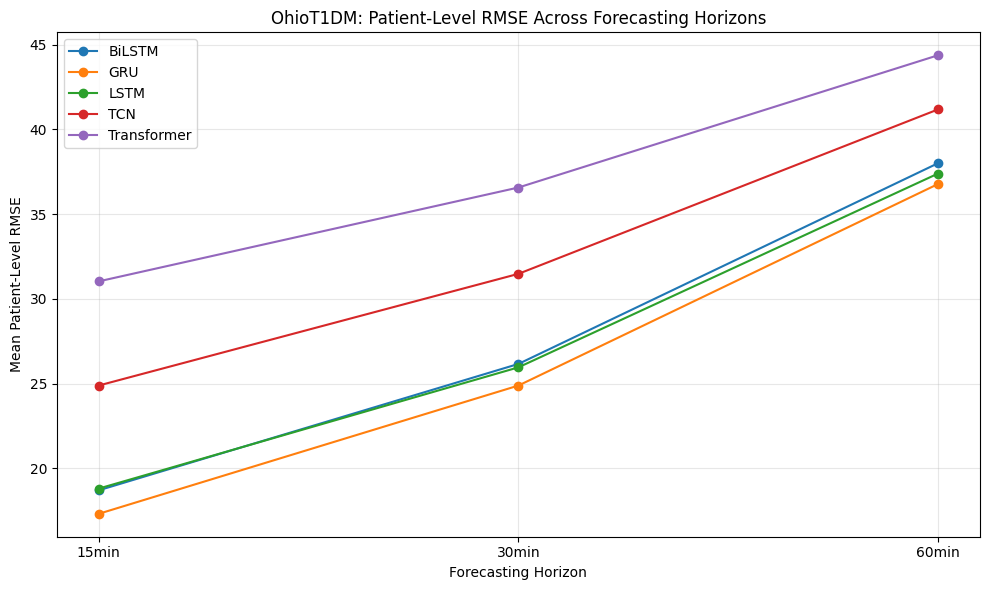

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

for architecture in patient_rmse["Architecture"].unique():
    subset = patient_rmse[patient_rmse["Architecture"] == architecture]
    
    means = (
        subset.groupby("Horizon")["RMSE"]
        .mean()
        .reindex(["15min", "30min", "60min"])
    )
    
    plt.plot(
        means.index,
        means.values,
        marker="o",
        label=architecture
    )

plt.xlabel("Forecasting Horizon")
plt.ylabel("Mean Patient-Level RMSE")
plt.title("OhioT1DM: Patient-Level RMSE Across Forecasting Horizons")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 14. Shanghai Dataset Analysis

The Shanghai dataset was used as an additional evaluation dataset to investigate the generalizability of the CGM forecasting pipeline beyond the OhioT1DM cohort.

The Shanghai preprocessing and forecasting pipeline is implemented in the corresponding Python modules in this repository. The notebook loads the generated experimental results for verification and analysis.

## Shanghai Experimental Pipeline

The Shanghai experiments follow the forecasting workflow used for the OhioT1DM experiments, including data preprocessing, sequence construction, model training, forecasting at multiple prediction horizons, and evaluation using the implemented forecasting metrics.

The raw Shanghai dataset is maintained separately and is not included in the public repository. The processed experimental results are retained in the repository for analysis and reproducibility.

In [9]:
# Load Shanghai architecture comparison results

shanghai_results = pd.read_csv(
    output_dir / "shanghai_t1dm_architecture_results.csv"
)

shanghai_summary = pd.read_csv(
    output_dir / "shanghai_t1dm_architecture_summary.csv"
)

print("Shanghai results shape:", shanghai_results.shape)
print("Shanghai summary shape:", shanghai_summary.shape)

print("\nShanghai result columns:")
print(shanghai_results.columns.tolist())

print("\nShanghai summary columns:")
print(shanghai_summary.columns.tolist())

Shanghai results shape: (180, 12)
Shanghai summary shape: (15, 12)

Shanghai result columns:
['Patient', 'Horizon', 'Architecture', 'RMSE', 'MAE', 'MARD', 'TimeLag_min', 'CEGA_A_%', 'CEGA_B_%', 'CEGA_C_%', 'CEGA_D_%', 'CEGA_E_%']

Shanghai summary columns:
['Horizon', 'Architecture', 'n_patients', 'RMSE', 'MAE', 'MARD', 'TimeLag_min', 'CEGA_A_%', 'CEGA_B_%', 'CEGA_C_%', 'CEGA_D_%', 'CEGA_E_%']


## Shanghai Architecture Comparison Results

The Shanghai experiment contains patient-level results for the three forecasting horizons (15, 30, and 60 minutes) and the five forecasting architectures used in the OhioT1DM architecture comparison.

The evaluation retains the same clinical and forecasting metrics:
- RMSE
- MAE
- MARD
- Time Lag
- Clarke Error Grid Analysis (CEGA) zones A–E

In [10]:
# Display Shanghai patient-level architecture results

display(shanghai_results)

,Patient,Horizon,Architecture,RMSE,MAE,MARD,TimeLag_min,CEGA_A_%,CEGA_B_%,CEGA_C_%,CEGA_D_%,CEGA_E_%
0,1001,15min,LSTM,16.30,11.64,6.33,0.0,96.88,3.12,0.00,0.00,0.00
1,1001,15min,GRU,14.71,10.99,6.04,0.0,97.66,2.34,0.00,0.00,0.00
2,1001,15min,BiLSTM,15.79,11.14,6.11,0.0,97.66,2.34,0.00,0.00,0.00
3,1001,15min,TCN,17.71,12.90,6.98,0.0,95.31,4.69,0.00,0.00,0.00
4,1001,15min,Transformer,15.41,11.51,6.69,0.0,95.31,4.69,0.00,0.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...
175,1012,60min,LSTM,54.12,39.91,28.50,0.0,54.41,34.87,2.68,7.28,0.77
176,1012,60min,GRU,63.56,50.27,32.78,0.0,41.76,46.74,1.53,9.20,0.77
177,1012,60min,BiLSTM,55.13,40.64,28.73,0.0,58.62,30.65,2.68,7.28,0.77
178,1012,60min,TCN,67.91,52.17,36.61,0.0,45.21,41.38,2.68,9.20,1.53


## Shanghai Mean ± SD Summary

The following table summarizes the Shanghai results across the available patients for each forecasting horizon and architecture. The summary is retained separately from the patient-level results so that patient-level variability is not lost.

In [11]:
# Display Shanghai mean ± SD summary

display(shanghai_summary)

,Horizon,Architecture,n_patients,RMSE,MAE,MARD,TimeLag_min,CEGA_A_%,CEGA_B_%,CEGA_C_%,CEGA_D_%,CEGA_E_%
0,15min,BiLSTM,12,16.29 ± 4.09,12.68 ± 3.78,11.11 ± 5.25,0.00 ± 0.00,87.14 ± 11.92,10.23 ± 11.43,0.00 ± 0.00,2.63 ± 3.32,0.00 ± 0.00
1,15min,GRU,12,14.59 ± 4.56,11.21 ± 3.78,9.44 ± 3.95,0.00 ± 0.00,88.58 ± 11.82,9.39 ± 11.47,0.00 ± 0.00,2.03 ± 2.02,0.00 ± 0.00
2,15min,LSTM,12,18.82 ± 6.02,14.49 ± 4.87,11.92 ± 5.02,0.00 ± 0.00,84.49 ± 12.27,13.10 ± 11.70,0.00 ± 0.00,2.41 ± 2.37,0.00 ± 0.00
3,15min,TCN,12,20.08 ± 6.23,15.44 ± 5.01,12.70 ± 5.30,0.00 ± 0.00,82.20 ± 11.35,15.24 ± 11.98,0.00 ± 0.00,2.55 ± 2.42,0.00 ± 0.00
4,15min,Transformer,12,24.59 ± 9.82,18.86 ± 7.99,16.80 ± 9.71,0.00 ± 0.00,77.73 ± 13.64,19.04 ± 13.58,0.16 ± 0.55,3.08 ± 2.72,0.00 ± 0.00
5,30min,BiLSTM,12,23.14 ± 6.44,17.90 ± 5.36,15.26 ± 6.61,0.00 ± 0.00,77.84 ± 12.89,18.34 ± 12.75,0.13 ± 0.44,3.69 ± 4.08,0.00 ± 0.00
6,30min,GRU,12,20.51 ± 4.58,15.97 ± 4.21,13.98 ± 5.69,0.00 ± 0.00,79.39 ± 11.60,17.01 ± 11.88,0.00 ± 0.00,3.60 ± 3.89,0.00 ± 0.00
7,30min,LSTM,12,27.00 ± 10.86,21.52 ± 8.98,17.22 ± 7.19,0.00 ± 0.00,72.69 ± 14.46,23.27 ± 13.77,0.09 ± 0.33,3.91 ± 3.80,0.03 ± 0.11
8,30min,TCN,12,25.91 ± 10.51,20.23 ± 8.44,16.63 ± 6.32,0.00 ± 0.00,72.71 ± 13.88,23.01 ± 13.73,0.09 ± 0.33,4.16 ± 3.72,0.03 ± 0.11
9,30min,Transformer,12,30.98 ± 11.79,24.28 ± 10.11,22.09 ± 12.39,0.00 ± 0.00,67.13 ± 17.51,25.53 ± 15.49,0.16 ± 0.55,7.15 ± 11.06,0.03 ± 0.11


## Shanghai Forecasting Performance Across Horizons

The Shanghai results are examined across the three forecasting horizons to assess how forecasting performance changes as the prediction horizon increases. The five architectures are compared using RMSE, MAE, and MARD, while the clinical metrics provide additional assessment of prediction quality.

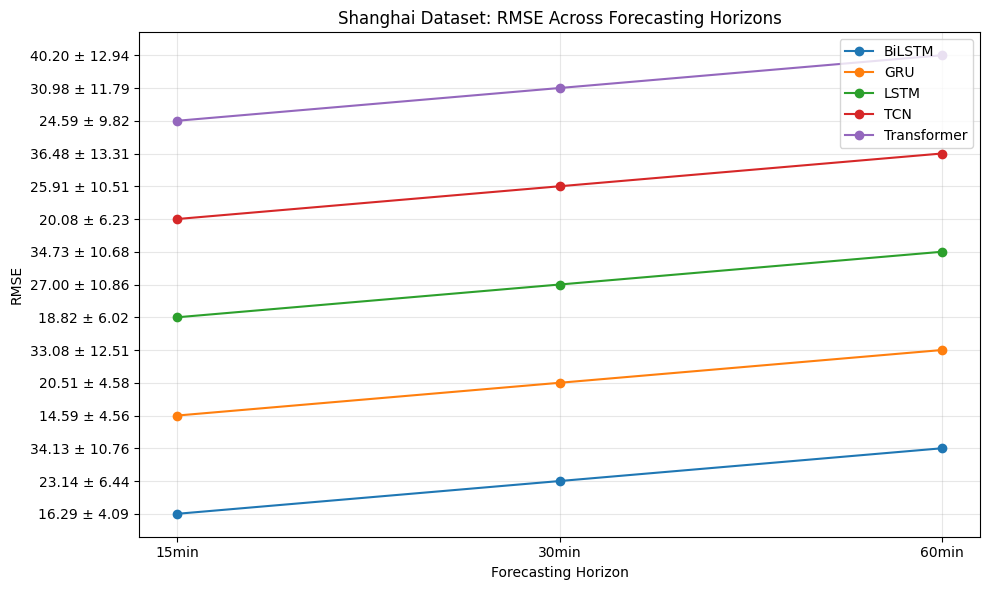

In [12]:
# Shanghai RMSE comparison across forecasting horizons

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

for architecture in shanghai_summary["Architecture"].unique():
    data = shanghai_summary[
        shanghai_summary["Architecture"] == architecture
    ]
    
    plt.plot(
        data["Horizon"],
        data["RMSE"],
        marker="o",
        label=architecture
    )

plt.xlabel("Forecasting Horizon")
plt.ylabel("RMSE")
plt.title("Shanghai Dataset: RMSE Across Forecasting Horizons")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Shanghai Generalizability Analysis

The Shanghai experiment provides an independent dataset-level evaluation of the forecasting pipeline developed using OhioT1DM. The results are examined using the same forecasting horizons, model architectures, and clinical evaluation metrics, allowing the behavior of the architectures to be compared across datasets.

Differences between OhioT1DM and Shanghai results are interpreted as dataset-dependent variation rather than assuming that performance observed on one dataset will necessarily transfer directly to another.

## OhioT1DM vs Shanghai: Cross-Dataset Comparison

To examine dataset-level differences, the mean RMSE obtained on OhioT1DM and Shanghai is compared for the same forecasting horizons and model architectures.

The comparison is descriptive and is intended to identify similarities and differences in forecasting behavior across the two datasets.

In [14]:
# Prepare Ohio and Shanghai mean RMSE values for comparison

# Create Ohio summary from the existing patient-level results
ohio_compare = (
    ohio_results
    .groupby(["Horizon", "Architecture"])["RMSE"]
    .mean()
    .reset_index()
)

# Shanghai summary is already available
shanghai_compare = (
    shanghai_results
    .groupby(["Horizon", "Architecture"])["RMSE"]
    .mean()
    .reset_index()
)

# Add dataset labels
ohio_compare["Dataset"] = "OhioT1DM"
shanghai_compare["Dataset"] = "Shanghai"

# Combine both datasets
cross_dataset_rmse = pd.concat(
    [ohio_compare, shanghai_compare],
    ignore_index=True
)

display(cross_dataset_rmse)

,Horizon,Architecture,RMSE,Dataset
0,15min,BiLSTM,18.709167,OhioT1DM
1,15min,GRU,17.322500,OhioT1DM
2,15min,LSTM,18.810833,OhioT1DM
3,15min,TCN,24.892500,OhioT1DM
4,15min,Transformer,31.038333,OhioT1DM
5,30min,BiLSTM,26.165000,OhioT1DM
6,30min,GRU,24.889167,OhioT1DM
7,30min,LSTM,25.964167,OhioT1DM
8,30min,TCN,31.481667,OhioT1DM
9,30min,Transformer,36.575833,OhioT1DM


### Cross-Dataset RMSE Comparison

The following visualization compares the mean RMSE across OhioT1DM and Shanghai for each forecasting horizon and architecture.

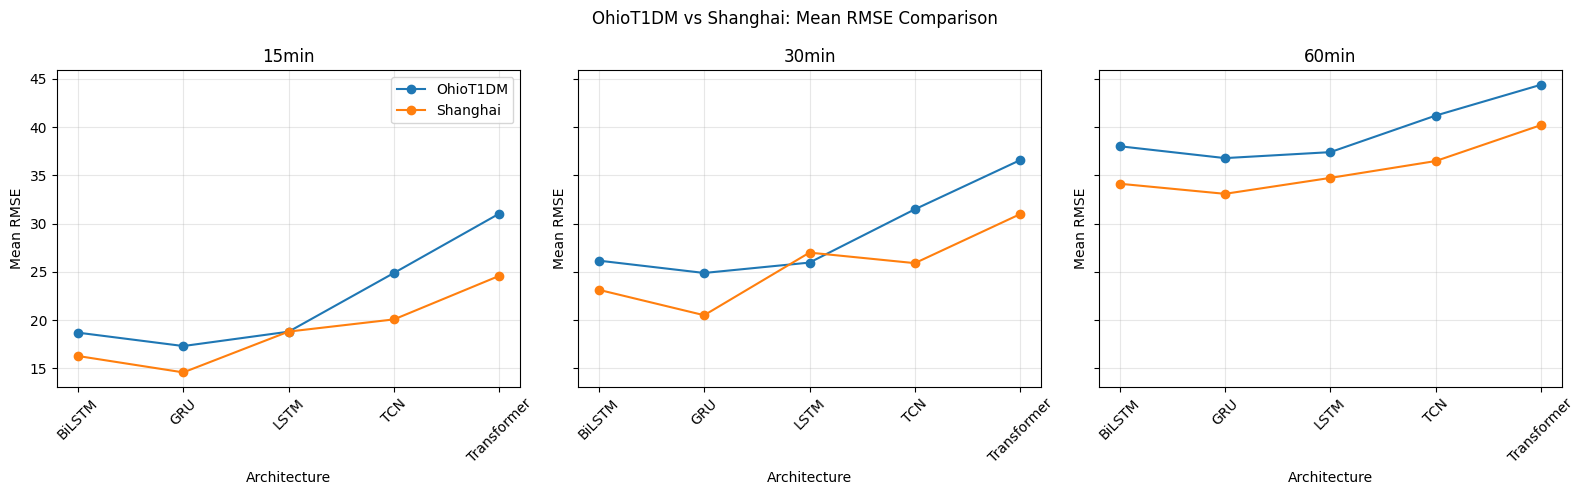

In [15]:
# Cross-dataset RMSE comparison

fig, axes = plt.subplots(
    1, 3,
    figsize=(16, 5),
    sharey=True
)

horizons = ["15min", "30min", "60min"]

for ax, horizon in zip(axes, horizons):
    data = cross_dataset_rmse[
        cross_dataset_rmse["Horizon"] == horizon
    ]

    for dataset in data["Dataset"].unique():
        dataset_data = data[data["Dataset"] == dataset]

        ax.plot(
            dataset_data["Architecture"],
            dataset_data["RMSE"],
            marker="o",
            label=dataset
        )

    ax.set_title(horizon)
    ax.set_xlabel("Architecture")
    ax.set_ylabel("Mean RMSE")
    ax.tick_params(axis="x", rotation=45)
    ax.grid(True, alpha=0.3)

axes[0].legend()
plt.suptitle("OhioT1DM vs Shanghai: Mean RMSE Comparison")
plt.tight_layout()
plt.show()

## Cross-Dataset Interpretation

The cross-dataset comparison examines the mean RMSE of the five forecasting architectures across the 15-minute, 30-minute, and 60-minute forecasting horizons on OhioT1DM and Shanghai datasets.

Across the evaluated horizons, the Shanghai dataset shows lower mean RMSE values than OhioT1DM for most architecture-horizon combinations. However, these values should be interpreted in the context of dataset-specific characteristics, including patient populations, glucose distributions, sampling patterns, and available input signals.

The relative ordering of architectures also varies across datasets and forecasting horizons. Therefore, performance observed on OhioT1DM should not be assumed to transfer directly to Shanghai or to other CGM datasets.

The cross-dataset experiment provides an independent evaluation of how the forecasting pipeline behaves under a different dataset and supports assessment of dataset-dependent variability in model performance.

# 15. Overall Discussion and Experimental Conclusions

## Overall Discussion

The experiments evaluated five forecasting architectures—LSTM, GRU, BiLSTM, TCN, and Transformer—across three forecasting horizons of 15, 30, and 60 minutes.

The OhioT1DM experiments were conducted across 12 patients, retaining patient-level results in addition to aggregate Mean ± SD summaries. This allows both overall model behavior and inter-patient variability to be examined.

The evaluation included RMSE, MAE, MARD, Time Lag, and Clarke Error Grid Analysis. Statistical comparisons were performed using patient-level RMSE values to examine differences between GRU and the other architectures.

The wearable-feature experiment further examined whether adding wearable-derived signals changed forecasting performance for the six 2018 OhioT1DM patients.

The Shanghai experiments extended the evaluation to an independent dataset using the same forecasting horizons and model architectures. The resulting cross-dataset comparison demonstrates that model performance can vary across datasets and therefore provides a basis for evaluating generalizability.

## Main Experimental Observations

- Forecasting error generally increases as the prediction horizon increases from 15 to 30 to 60 minutes.
- Architecture performance varies with forecasting horizon and dataset.
- Patient-level results show variability between individual subjects.
- Aggregate Mean ± SD values provide a population-level summary while retaining patient-level results for detailed analysis.
- Statistical testing shows that several GRU comparisons are statistically significant, while the GRU–LSTM comparison at 60 minutes is not statistically significant in the reported analysis.
- The wearable-feature experiment provides a separate assessment of the contribution of wearable-derived signals.
- Shanghai provides an independent dataset-level evaluation of the forecasting pipeline and highlights dataset-dependent variation in model performance.

## Limitations and Future Work

The current experiments provide a comparative evaluation of five architectures on OhioT1DM and Shanghai datasets. Further work can investigate additional architectures such as N-BEATS and TFT, as well as additional analysis of the observed OhioT1DM results.

Future experiments can also investigate the causes of patient-level variability, dataset differences, and the contribution of different input feature groups.

In [16]:
print("Experimental workflow completed.")
print("OhioT1DM: 12 patients")
print("Shanghai: 12 patients")
print("Architectures: LSTM, GRU, BiLSTM, TCN, Transformer")
print("Horizons: 15, 30, 60 minutes")
print("Evaluation: RMSE, MAE, MARD, Time Lag, CEGA")

Experimental workflow completed.
OhioT1DM: 12 patients
Shanghai: 12 patients
Architectures: LSTM, GRU, BiLSTM, TCN, Transformer
Horizons: 15, 30, 60 minutes
Evaluation: RMSE, MAE, MARD, Time Lag, CEGA
